# Lohoff Figure 2a recreation

Run TissueAgent with the seqFISH dataset and canonical 2a reference. No colormap file is supplied.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import re
import shutil
import subprocess
import sys
import tempfile
from datetime import datetime, timezone

from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "pyproject.toml").exists(), "Run this notebook from demo/ or the repository root."

TASK_NAME = "figure_recreation_lohoff-2a"
TASK_ID = "notebook_lohoff_2a_no_colormap"
DATASET = REPO_ROOT / "demo/data/dataset_lohoff_et_al_seqfish.h5ad"
REFERENCE = REPO_ROOT / "demo/data/reference_lohoff-2a.png"
OUTPUT_DIR = REPO_ROOT / "demo/outputs" / TASK_NAME
PROMPT = (
    "I have provided a spatial transcriptomics seqFISH dataset in dataset_lohoff_et_al_seqfish.h5ad. "
    "Create a side-by-side UMAP figure comparing panels titled Gastrulation atlas and seqFISH, "
    "with cells colored by cell type and shared UMAP1 and UMAP2 labeling. Use the seqFISH coordinates "
    "stored in obsm['X_umap']. Do not fabricate an unavailable atlas population; document any limitation "
    "caused by absent atlas source data. A reference image is included in reference_lohoff-2a.png. "
    "Make the supported plot content and overall layout as close as possible to the reference."
)
ATTACHMENTS = [REFERENCE]
INPUTS = [DATASET, *ATTACHMENTS]
ROLES = {
    DATASET.name: "dataset",
    REFERENCE.name: "reference",
}

for path in INPUTS:
    assert path.is_file(), f"Missing input: {path}"
assert not re.search(r"colormap|palette", PROMPT, flags=re.IGNORECASE)
assert [path.name for path in INPUTS] == [
    "dataset_lohoff_et_al_seqfish.h5ad",
    "reference_lohoff-2a.png"
]
print(json.dumps({
    "task": TASK_NAME,
    "dataset": str(DATASET),
    "attachments": [str(path) for path in ATTACHMENTS],
    "supplied_colormap": False,
    "output_dir": str(OUTPUT_DIR),
}, indent=2))


{
  "task": "figure_recreation_lohoff-2a",
  "dataset": "/Users/wenduoc/TissueAgent/demo/data/dataset_lohoff_et_al_seqfish.h5ad",
  "attachments": [
    "/Users/wenduoc/TissueAgent/demo/data/reference_lohoff-2a.png"
  ],
  "supplied_colormap": false,
  "output_dir": "/Users/wenduoc/TissueAgent/demo/outputs/figure_recreation_lohoff-2a"
}


## Run the CLI

The full trace is written to the named output directory while this cell waits for completion.

In [2]:
manifest_path = OUTPUT_DIR / "run_manifest.json"
metrics_path = OUTPUT_DIR / "metrics.json"
if OUTPUT_DIR.is_dir() and manifest_path.is_file() and metrics_path.is_file():
    manifest = json.loads(manifest_path.read_text())
    metrics = json.loads(metrics_path.read_text())
    terminal_state = metrics.get("outcome", {}).get("terminal_state")
    assert terminal_state == "completed"
    assert manifest.get("supplied_colormap") is False
    print(json.dumps({
        "terminal_state": terminal_state,
        "elapsed_seconds": manifest["elapsed_seconds"],
        "output_dir": str(OUTPUT_DIR),
        "reused_completed_output": True,
    }, indent=2))
else:
    if OUTPUT_DIR.exists():
        raise RuntimeError(
            f"{OUTPUT_DIR} already exists. Archive or remove it explicitly before rerunning."
        )
    OUTPUT_DIR.mkdir(parents=True)
    STATE_ROOT = Path(tempfile.mkdtemp(prefix=f"{TASK_NAME}-", dir="/private/tmp"))
    (OUTPUT_DIR / "state_root.txt").write_text(str(STATE_ROOT) + "\n")

    env = os.environ.copy()
    env.update({
        "TISSUEAGENT_STATE_ROOT": str(STATE_ROOT),
        "TISSUEAGENT_GATEWAY_PORT": "8893",
        "NUMBA_CACHE_DIR": f"/private/tmp/tissueagent-numba-{TASK_NAME}",
        "MPLCONFIGDIR": f"/private/tmp/tissueagent-mpl-{TASK_NAME}",
        "XDG_CACHE_HOME": f"/private/tmp/tissueagent-xdg-{TASK_NAME}",
    })
    command = [
        sys.executable, "-m", "cli",
        "--no-docker",
        "--json",
        "--task-id", TASK_ID,
        "--seed", "0",
        "--attempt", "1",
        "--metrics-out", str(metrics_path),
        "--dataset", str(DATASET),
    ]
    for attachment in ATTACHMENTS:
        command.extend(["--attach", str(attachment)])
    command.append(PROMPT)

    transcript_path = OUTPUT_DIR / "transcript.log"
    started_at = datetime.now(timezone.utc)
    with transcript_path.open("w") as transcript:
        completed = subprocess.run(
            command,
            cwd=REPO_ROOT,
            env=env,
            stdout=transcript,
            stderr=subprocess.STDOUT,
            text=True,
            check=False,
        )
    finished_at = datetime.now(timezone.utc)

    project_dir = STATE_ROOT / "workspace/project"
    project_outputs = project_dir / "outputs"
    if completed.returncode == 0:
        assert project_outputs.is_dir(), f"Missing project outputs: {project_outputs}"
        for source in project_outputs.iterdir():
            destination = OUTPUT_DIR / source.name
            if source.is_dir():
                shutil.copytree(source, destination, dirs_exist_ok=True)
            else:
                shutil.copy2(source, destination)
        shutil.copy2(project_dir / "metrics.json", OUTPUT_DIR / "project_metrics.json")

    if not metrics_path.is_file():
        raise RuntimeError(
            f"CLI exited {completed.returncode} without metrics. See {transcript_path}; "
            f"temporary state retained at {STATE_ROOT}."
        )
    metrics = json.loads(metrics_path.read_text())
    terminal_state = metrics.get("outcome", {}).get("terminal_state")
    run_prompt = metrics.get("run", {}).get("prompt", "")
    if completed.returncode != 0 or terminal_state != "completed":
        raise RuntimeError(
            f"CLI failed (exit={completed.returncode}, terminal_state={terminal_state}). "
            f"See {transcript_path}; temporary state retained at {STATE_ROOT}."
        )
    assert not re.search(r"colormap|palette", run_prompt, flags=re.IGNORECASE)

    input_records = [
        {
            "role": ROLES[path.name],
            "path": str(path),
            "name": path.name,
            "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
        }
        for path in INPUTS
    ]
    manifest = {
        "task": TASK_NAME,
        "task_id": TASK_ID,
        "started_at_utc": started_at.isoformat(),
        "finished_at_utc": finished_at.isoformat(),
        "elapsed_seconds": (finished_at - started_at).total_seconds(),
        "command": command,
        "prompt": PROMPT,
        "inputs": input_records,
        "supplied_colormap": False,
        "cli_exit_code": completed.returncode,
        "terminal_state": terminal_state,
    }
    manifest_path.write_text(json.dumps(manifest, indent=2) + "\n")
    (OUTPUT_DIR / "state_root.txt").unlink()
    shutil.rmtree(STATE_ROOT, ignore_errors=True)
    print(json.dumps({
        "terminal_state": terminal_state,
        "elapsed_seconds": manifest["elapsed_seconds"],
        "output_dir": str(OUTPUT_DIR),
    }, indent=2))


{
  "terminal_state": "completed",
  "elapsed_seconds": 593.34558,
  "output_dir": "/Users/wenduoc/TissueAgent/demo/outputs/figure_recreation_lohoff-2a"
}


## Final figure

demo/outputs/figure_recreation_lohoff-2a/figures/lohoff_2a_umap_recreation.png


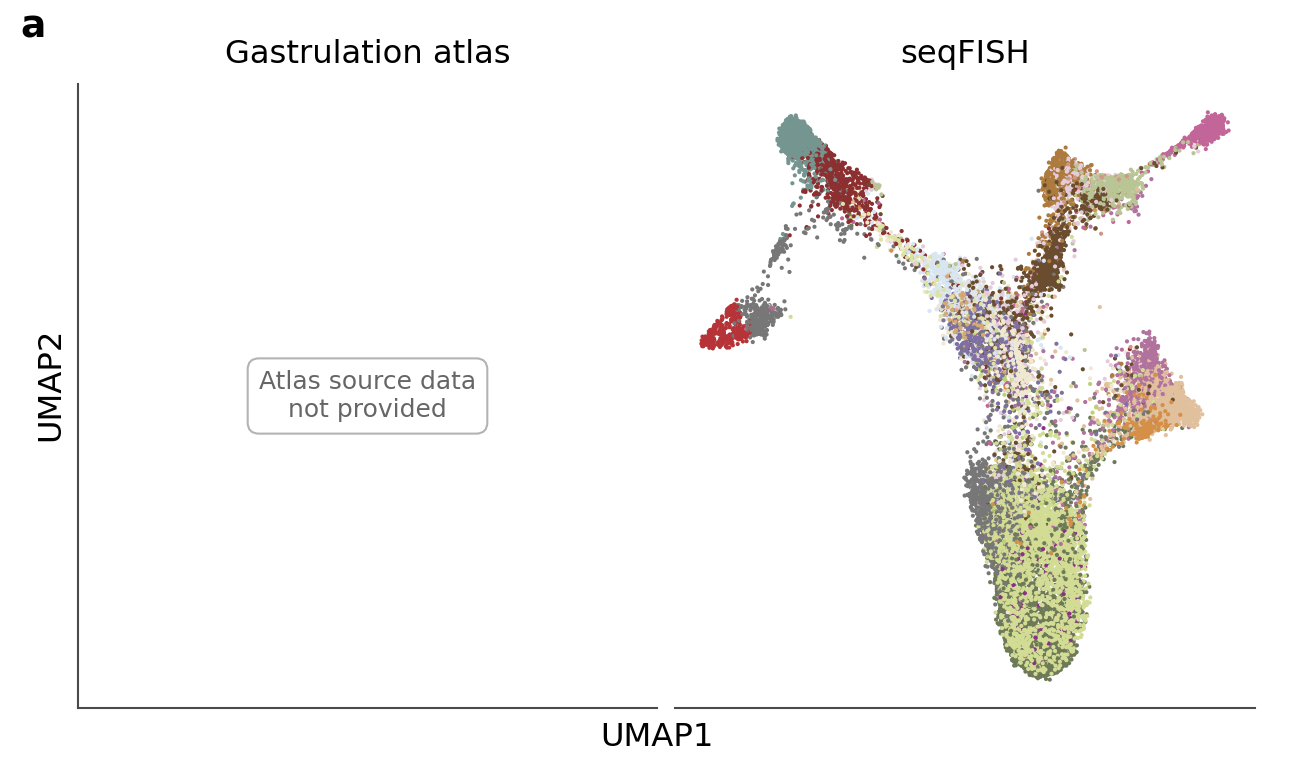

In [3]:
preferred = [
    OUTPUT_DIR / "figures/fig2a_umap_comparison.png",
    OUTPUT_DIR / "figures/lohoff_2a_umap.png",
    OUTPUT_DIR / "figures/umap_comparison.png",
]
pngs = sorted(OUTPUT_DIR.rglob("*.png"))
selected = next((path for path in preferred if path.is_file()), None)
if selected is None:
    clean = [
        path for path in pngs
        if not re.search(r"attempt|comparison|compare|diff|reference|crop", path.name, re.IGNORECASE)
    ]
    selected = max(clean or pngs, key=lambda path: path.stat().st_size)
print(selected.relative_to(REPO_ROOT))
display(Image(filename=str(selected)))
